In [7]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
PROJECT_DIR = Path.cwd()

if PROJECT_DIR.name == "notebooks":
    PROJECT_DIR = PROJECT_DIR.parent

if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

DATA_DIR = PROJECT_DIR / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"

MODELS_DIR = PROJECT_DIR / "models"

RESULTS_DIR = PROJECT_DIR / "results"
METRICS_DIR = RESULTS_DIR / "metrics"
FIGURES_DIR = RESULTS_DIR / "figures"

print("Project directory:", PROJECT_DIR)

Project directory: c:\Users\Korisnik\Desktop\github\imbalanced-transaction-fraud-detection-with-ensemble-learning\imbalanced-transaction-fraud-detection-with-ensemble-learning


In [12]:
from src.preprocessing import (
    load_data,
    split_features_target,
    split_dataset,
    scale_features,
    apply_smote
)

from src.modeling import (
    create_logistic_regression,
    create_random_forest,
    create_xgboost
)

from src.evaluation import (
    calculate_metrics,
    plot_confusion_matrix,
    create_metrics_table,
    plot_model_comparison
)

In [26]:
SEED = 42

DATA_PATH = RAW_DIR / "creditcard.csv"

In [14]:
df = load_data(DATA_PATH)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully.
Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [16]:
missing_values = df.isnull().sum()

print("Total missing values:", missing_values.sum())

Total missing values: 0


In [17]:
missing_values[missing_values > 0]

Series([], dtype: int64)

## Dataset Overview

The dataset contains anonymized credit card transactions.

Most input features (`V1`–`V28`) were transformed using Principal Component Analysis (PCA), while `Time` and `Amount` remain directly interpretable.

The target variable is `Class`:

- `0` – legitimate transaction
- `1` – fraudulent transaction

In [18]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.487313e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.213481e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.406331e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


In [19]:
class_counts = df["Class"].value_counts()

class_percentages = (
    df["Class"]
    .value_counts(normalize=True)
    .mul(100)
)

print("Class counts:")
print(class_counts)

print("\nClass percentages:")
print(class_percentages)

Class counts:
Class
0    284315
1       492
Name: count, dtype: int64

Class percentages:
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


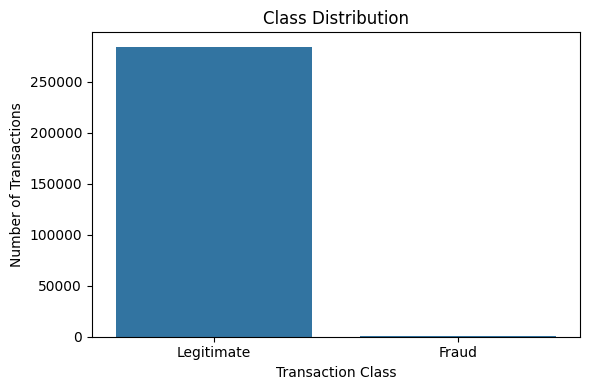

In [20]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="Class"
)

plt.title("Class Distribution")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")

plt.xticks(
    [0, 1],
    ["Legitimate", "Fraud"]
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "class_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The dataset is extremely imbalanced.

Fraudulent transactions represent only a very small fraction of all transactions. Because of this imbalance, accuracy alone is not sufficient for evaluating the models.

Metrics such as precision, recall and F1-score are more informative for this classification problem.

In [21]:
df.groupby("Class")["Amount"].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


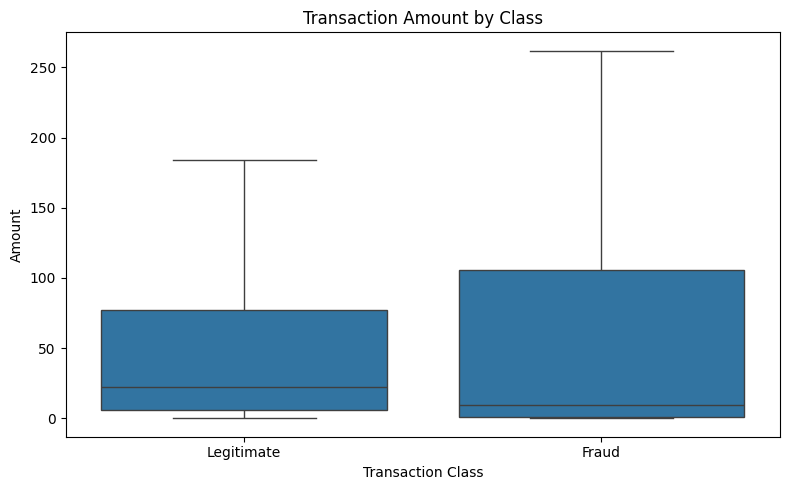

In [22]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Class",
    y="Amount",
    showfliers=False
)

plt.title("Transaction Amount by Class")
plt.xlabel("Transaction Class")
plt.ylabel("Amount")

plt.xticks(
    [0, 1],
    ["Legitimate", "Fraud"]
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "amount_by_class.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Feature and Target Separation

The dataset is divided into input features and the target variable `Class`.

In [23]:
X, y = split_features_target(
    df,
    target_column="Class"
)

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (284807, 30)
Target shape: (284807,)


## Train-Test Split

The dataset is divided into training and test sets using an 80/20 split.

Stratification is used to preserve the original class distribution in both subsets.

In [24]:
X_train, X_test, y_train, y_test = split_dataset(
    X,
    y,
    test_size=0.20,
    random_state=SEED
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (227845, 30)
X_test: (56962, 30)
y_train: (227845,)
y_test: (56962,)


In [25]:
print("Training class distribution:")
print(y_train.value_counts())

print("\nTest class distribution:")
print(y_test.value_counts())

Training class distribution:
Class
0    227451
1       394
Name: count, dtype: int64

Test class distribution:
Class
0    56864
1       98
Name: count, dtype: int64
